In [9]:
import glob as glob_module

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json

%config InlineBackend.figure_format='retina'

In [10]:
import os

AGENT_REGISTRY = [
    ("Claude", "../results/claude", "claude_"),
    ("Biomni", "../results/biomni", "biomni_"),
    ("Edison", "../results/edison_analysis", ""),
    ("GPT", "../results/gpt", "gpt_"),
]

AGENT_BASE_COLORS = {
    "Claude": "#c2c2c2",
    "Biomni": "#c2c2c2",
    "Edison": "#c2c2c2",
    "GPT": "#c2c2c2",
    "gget virus": "#DE7356",
}

def discover_sources(rerun=True, file_type="summary"):
    ext = ".csv" if file_type == "summary" else ".json"
    rerun_sfx = "_rerun_*" if rerun else ""
    sources = {}
    for agent, base_dir, prefix in AGENT_REGISTRY:
        if not os.path.isdir(base_dir):
            continue
        subdirs = sorted(
            e for e in os.listdir(base_dir)
            if os.path.isdir(os.path.join(base_dir, e)) and e != "pilot" and not e.startswith(".")
        )
        for model in subdirs:
            label = f"{agent} ({model})"
            d = f"{base_dir}/{model}"
            sources[label] = (f"{d}/{prefix}benchmark_{file_type}_*{rerun_sfx}{ext}", "_gv_")
            sources[f"{label} + gget"] = (f"{d}/{prefix}benchmark_{file_type}_gv_*{rerun_sfx}{ext}", None)
    gget_dir = "../results/gget_virus"
    if os.path.isdir(gget_dir):
        sources["gget virus"] = (f"{gget_dir}/gget_direct_benchmark_{file_type}_*{rerun_sfx}{ext}", None)
    return sources


def get_agent_base(tech_name):
    if tech_name == "gget virus":
        return "gget virus"
    name = tech_name.replace(" + gget", "")
    for base in AGENT_BASE_COLORS:
        if base != "gget virus" and name.startswith(base):
            return base
    return name.split(" (")[0]


FONTSIZE = 11

FIGSIZE = (8, 2)

In [11]:
MODEL_DISPLAY = [
    ("Claude (claude-sonnet-4-20250514)", "Claude Sonnet 4"),
    ("Biomni (claude-sonnet-4-20250514)", "Biomni"),
    ("Edison (2026-02-26)", "Edison Analysis"),
    ("GPT (gpt-5.2-pro)", "GPT 5.2 pro"),
    ("Claude (claude-opus-4-7)", "Claude Opus 4.7"),
    ("GPT (gpt-5.5)", "GPT 5.5"),
]

In [12]:
import yaml
with open("../config.yaml") as _f:
    _config = yaml.safe_load(_f)
configs = pd.read_csv(f"../{_config['benchmark_csv']}")
configs = configs[pd.to_numeric(configs["query_id"], errors="coerce").notna()]
configs["query_id"] = configs["query_id"].astype(int)
pathogen_map = configs.set_index("query_id")["pathogen"].to_dict()

rerun = True

NONE_TREATED_AS_ZERO = False

SOURCES = discover_sources(rerun=rerun, file_type="summary")

_renamed = {}
for _discovered, _display in MODEL_DISPLAY:
    if _discovered in SOURCES:
        _renamed[_display] = SOURCES[_discovered]
    _gget_key = f"{_discovered} + gget"
    if _gget_key in SOURCES:
        _renamed[f"{_display} + gget"] = SOURCES[_gget_key]
if "gget virus" in SOURCES:
    _renamed["gget virus"] = SOURCES["gget virus"]
SOURCES = _renamed

TECHNOLOGIES = list(SOURCES.keys())

COLORS = {}
XTICKLABEL_COLORS = {}
HATCH = {}
for t in TECHNOLOGIES:
    base = get_agent_base(t)
    COLORS[t] = AGENT_BASE_COLORS.get(base, "#000000")
    XTICKLABEL_COLORS[t] = AGENT_BASE_COLORS[base] if base == "gget virus" else "black"
    HATCH[t] = "//" if "+ gget" in t else None

In [13]:
def load_benchmark(file_pattern, exclude_substring=None, return_path=False):
    files = sorted(glob_module.glob(file_pattern))
    if exclude_substring:
        files = [f for f in files if exclude_substring not in f]
    if not files:
        raise FileNotFoundError(f"No files matching {file_pattern}")
    file_path = files[-1]
    df = pd.read_csv(file_path)

    query_ids = sorted(df["query_id"].unique())
    n_runs = df["run_number"].nunique()

    expected = np.full(len(query_ids), np.nan)
    runs = np.full((len(query_ids), n_runs), np.nan)
    durations = np.full((len(query_ids), n_runs), np.nan)
    n_errors = 0
    n_nones = 0

    for i, qid in enumerate(query_ids):
        group = df[df["query_id"] == qid].sort_values("run_number")
        expected[i] = group["expected_count"].iloc[0]
        for _, row in group.iterrows():
            j = int(row["run_number"]) - 1

            error_val = row.get("error", "")
            has_error = (
                error_val is not None
                and not pd.isnull(error_val)
                and str(error_val).strip() != ""
            )

            if has_error:
                runs[i, j] = np.nan
                durations[i, j] = np.nan
                n_errors += 1
                continue

            retrieved = row.get("retrieved_count", np.nan)
            retrieved_missing = (
                pd.isnull(retrieved)
                or retrieved is None
                or (isinstance(retrieved, str) and retrieved.lower() == "error")
                or retrieved == ""
            )
            if retrieved_missing:
                n_nones += 1
                runs[i, j] = 0 if NONE_TREATED_AS_ZERO else np.nan
            else:
                runs[i, j] = retrieved

            dur = row.get("duration_seconds", np.nan)
            if pd.isnull(dur) or dur is None or (isinstance(dur, str) and dur.lower() == "error") or dur == "":
                durations[i, j] = np.nan
            else:
                durations[i, j] = dur

    if return_path:
        return query_ids, expected, runs, durations, n_errors, n_nones, file_path
    else:
        return query_ids, expected, runs, durations, n_errors, n_nones

data = {}
loaded_paths = {}
for name in TECHNOLOGIES:
    pattern, exclude = SOURCES[name]
    try:
        qids, exp, runs, dur, n_errors, n_nones, file_path = load_benchmark(pattern, exclude_substring=exclude, return_path=True)
    except FileNotFoundError:
        alt_pattern = pattern.replace("_rerun_", "_")
        try:
            print(f"[INFO] Rerun files not found for {name}. Falling back to non-rerun benchmark summary files.")
            qids, exp, runs, dur, n_errors, n_nones, file_path = load_benchmark(alt_pattern, exclude_substring=exclude, return_path=True)
        except FileNotFoundError:
            raise FileNotFoundError(f"No benchmark summary files found for {name}: tried {pattern} and {alt_pattern}")
    data[name] = {
        "query_ids": qids, "expected": exp, "runs": runs, "durations": dur,
        "n_errors": n_errors, "n_nones": n_nones,
    }
    loaded_paths[name] = file_path

print("Benchmark summary files loaded per model:")
for model, path in loaded_paths.items():
    print(f"  {model}: {path}")

[INFO] Rerun files not found for Claude Opus 4.7. Falling back to non-rerun benchmark summary files.
[INFO] Rerun files not found for Claude Opus 4.7 + gget. Falling back to non-rerun benchmark summary files.
Benchmark summary files loaded per model:
  Claude Sonnet 4: ../results/claude/claude-sonnet-4-20250514/claude_benchmark_summary_20260226_211231_rerun_20260302_120413.csv
  Claude Sonnet 4 + gget: ../results/claude/claude-sonnet-4-20250514/claude_benchmark_summary_gv_20260227_112923_rerun_20260302_123424.csv
  Biomni: ../results/biomni/claude-sonnet-4-20250514/biomni_benchmark_summary_20260226_211315_rerun_20260302_095413.csv
  Biomni + gget: ../results/biomni/claude-sonnet-4-20250514/biomni_benchmark_summary_gv_20260227_113135_rerun_20260302_105027.csv
  Edison Analysis: ../results/edison_analysis/2026-02-26/benchmark_summary_20260226_211213_rerun_20260301_213842.csv
  Edison Analysis + gget: ../results/edison_analysis/2026-02-26/benchmark_summary_gv_20260227_113028_rerun_2026030

In [14]:
def accuracy_per_case(expected, runs):
    matches = runs == expected[:, None]
    not_nan = ~np.isnan(runs)
    fraction_match = np.full(runs.shape[0], np.nan)
    for i in range(runs.shape[0]):
        valid = not_nan[i]
        n_valid = np.sum(valid)
        if n_valid == 0:
            fraction_match[i] = np.nan
        else:
            fraction_match[i] = np.sum(matches[i][valid]) / n_valid
    return fraction_match

metrics = {}
for name in TECHNOLOGIES:
    d = data[name]
    acc = accuracy_per_case(d["expected"], d["runs"])
    metrics[name] = {"accuracy": acc}

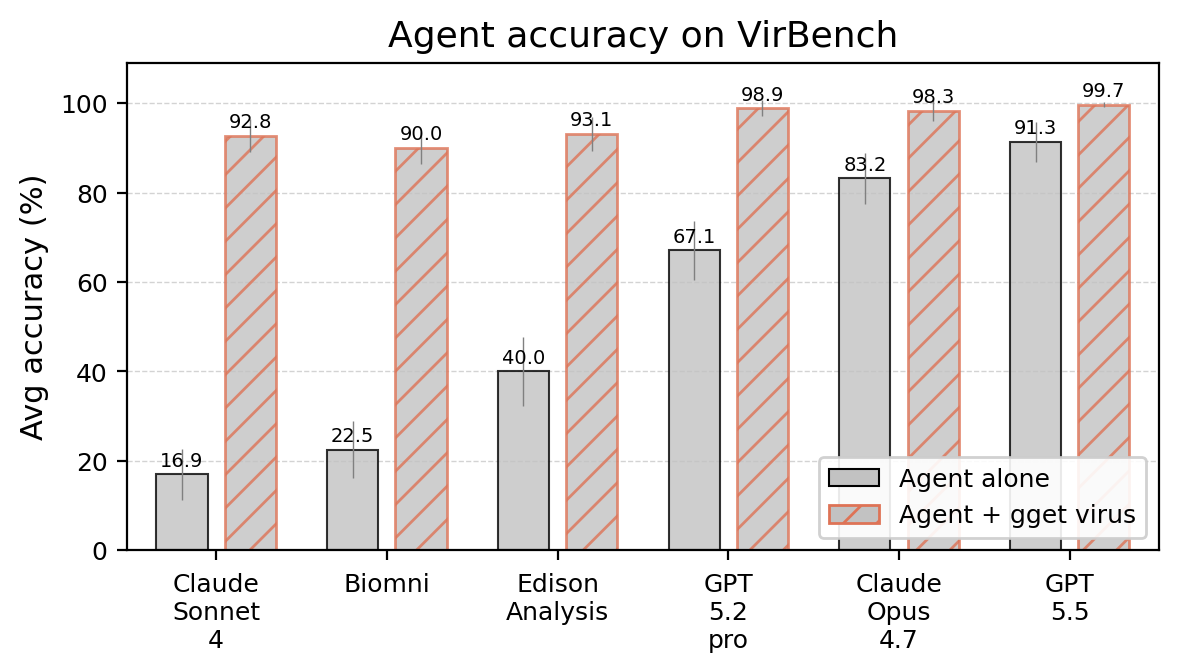

In [24]:
from scipy import stats
import matplotlib.patches as mpatches

SHOW_GGET_VIRUS = False

WITHIN_GROUP_BAR_GAP = 0.1

base_techs = [t for t in TECHNOLOGIES if "+ gget" not in t and t != "gget virus"]
GROUPED_TECHNOLOGIES = []
GROUPED_LABELS = []
for base in base_techs:
    gget_name = f"{base} + gget"
    if gget_name in SOURCES:
        GROUPED_TECHNOLOGIES.append((base, gget_name))
    else:
        GROUPED_TECHNOLOGIES.append((base,))
    GROUPED_LABELS.append(base.replace(" ", "\n"))
if SHOW_GGET_VIRUS and "gget virus" in SOURCES:
    GROUPED_TECHNOLOGIES.append(("gget virus",))
    GROUPED_LABELS.append("gget\nvirus")

group_bar_width = 0.3
n_groups = len(GROUPED_TECHNOLOGIES)

bar_x = []
group_centers = []
x_pos = 0.0
for i, group in enumerate(GROUPED_TECHNOLOGIES):
    if len(group) == 2:
        bar1_x = x_pos - (group_bar_width/2 + WITHIN_GROUP_BAR_GAP/2)
        bar2_x = x_pos + (group_bar_width/2 + WITHIN_GROUP_BAR_GAP/2)
        bar_x += [bar1_x, bar2_x]
        group_centers.append(x_pos)
        x_pos += 1.0
    else:
        bar_x.append(x_pos)
        group_centers.append(x_pos)
        x_pos += 1.0

bar_positions = np.array(bar_x)
group_centers = np.array(group_centers)

def compute_ci95(values):
    valid = values[~np.isnan(values)]
    n = len(valid)
    if n > 1:
        sd = np.std(valid, ddof=1)
        sem = sd / np.sqrt(n)
        t_crit = stats.t.ppf(0.975, df=n - 1)
        return t_crit * sem
    return 0.0

def make_bars_grouped(ax, values, errors):
    bar_colors = []
    hatches = []
    edgecols = []
    lwds = []
    for group in GROUPED_TECHNOLOGIES:
        if len(group) == 2:
            bar_colors += [COLORS[group[0]], COLORS[group[1]]]
            hatches += ['', HATCH.get(group[1], '')]
            edgecols += ["black", COLORS["gget virus"]]
            lwds += [0.75, 1]
        else:
            bar_colors += [COLORS[group[0]]]
            hatches += ['']
            edgecols += [COLORS["gget virus"] if "gget" in group[0] else "black"]
            lwds += [1 if "gget" in group[0] else 0.75]

    bars = []
    for i in range(len(bar_positions)):
        bars.append(ax.bar(
            [bar_positions[i]],
            [values[i]],
            yerr=[errors[i]],
            capsize=0,
            width=group_bar_width,
            color=bar_colors[i],
            edgecolor=edgecols[i],
            lw=lwds[i],
            alpha=0.8,
            ecolor="grey",
            error_kw=dict(lw=0.5, capthick=0),
            hatch=hatches[i]
        )[0])
    return bars

def set_grouped_xticklabels(ax, fontsize=FONTSIZE - 2):
    ax.set_xticks(group_centers)
    ax.set_xticklabels(["" for _ in GROUPED_LABELS], fontsize=fontsize)
    y_base = -8
    common = dict(
        ha="center", va="top", fontsize=fontsize,
        annotation_clip=False,
    )

    color_map = []
    for group in GROUPED_TECHNOLOGIES:
        base_color = XTICKLABEL_COLORS[group[0]]
        color_map.append((base_color,))

    for i, label in enumerate(GROUPED_LABELS):
        x = group_centers[i]
        colors = color_map[i]
        kw = common.copy()
        # Only bold if the label is "gget virus"; do not bold the last ticklabel unless it is actually "gget virus"
        if label.replace('\n',' ') == "gget virus":
            kw["fontweight"] = "bold"
        ax.annotate(label, xy=(x, 0), xycoords=("data", "axes fraction"),
                    xytext=(0, y_base), textcoords="offset points",
                    color=colors[0], **kw)

def agg_grouped_flat(groups, field):
    values = []
    errors = []
    for group in groups:
        if len(group) == 2:
            vals1 = np.array(metrics[group[0]][field])
            vals2 = np.array(metrics[group[1]][field])
            if field == "accuracy":
                values.extend([np.nanmean(vals1)*100, np.nanmean(vals2)*100])
                errors.extend([compute_ci95(vals1)*100, compute_ci95(vals2)*100])
            else:
                values.extend([np.nanmean(vals1), np.nanmean(vals2)])
                errors.extend([compute_ci95(vals1), compute_ci95(vals2)])
        else:
            vals = np.array(metrics[group[0]][field])
            if field == "accuracy":
                values.append(np.nanmean(vals)*100)
                errors.append(compute_ci95(vals)*100)
            else:
                values.append(np.nanmean(vals))
                errors.append(compute_ci95(vals))
    return values, errors

BAR_LABEL_FONTSIZE = FONTSIZE - 4
Y_LABEL_FONTSIZE = FONTSIZE - 2

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.set_axisbelow(True)
ax.yaxis.grid(True, color="lightgrey", linestyle="--", linewidth=0.5)
acc_means, acc_sd = agg_grouped_flat(GROUPED_TECHNOLOGIES, "accuracy")
bars = make_bars_grouped(ax, acc_means, acc_sd)
for i, bar in enumerate(bars):
    val = acc_means[i]
    ax.text(bar.get_x() + bar.get_width()/2, val + 1, f"{val:.1f}", ha="center", va="bottom", fontsize=BAR_LABEL_FONTSIZE)
set_grouped_xticklabels(ax)
ax.set_ylim(0, 109)
ax.margins(x=0.03)
ax.set_ylabel("Avg accuracy (%)", fontsize=FONTSIZE)
ax.set_title("Agent accuracy on VirBench", fontsize=FONTSIZE + 2)
ax.tick_params(axis="y", labelsize=Y_LABEL_FONTSIZE)

legend_agent = mpatches.Patch(facecolor="#c2c2c2", edgecolor="black", linewidth=0.75, alpha=1, label="Agent alone")
legend_agent_gget = mpatches.Patch(facecolor="#c2c2c2", edgecolor=AGENT_BASE_COLORS["gget virus"], linewidth=1, alpha=1, hatch="//", label="Agent + gget virus")
legend = ax.legend(handles=[legend_agent, legend_agent_gget], fontsize=FONTSIZE - 2, loc="lower right")
legend.get_frame().set_alpha(0.9)

plt.tight_layout()
plt.savefig("../figures/blog_accuracy.png", dpi=300, bbox_inches="tight")
plt.show()